# Enterprise Fraud Detection System

This project implements an end-to-end fraud detection pipeline using **XGBoost** and **Gradio**. It addresses severe class imbalance in financial transaction data to achieve high precision and reliable detection.

### **Key Features**
*   **Class Imbalance Handling:** Utilizes `scale_pos_weight` for cost-sensitive learning.
*   **Precision Optimization:** Fine-tuned to minimize false positives (96% Precision).
*   **Production Dashboard:** A batch-processing Gradio interface for enterprise use-cases.
*   **Explainability:** Integrated SHAP values for model transparency.

In [1]:
!pip install xgboost shap imbalanced-learn scikit-learn joblib pandas matplotlib seaborn

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import shap
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, f1_score, recall_score,
    precision_score, roc_curve, accuracy_score, average_precision_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Set plotting style
sns.set(style='whitegrid')
%matplotlib inline

## Load Dataset
Note: The dataset is large. We will attempt to download it from a public mirror or you can upload `creditcard.csv` to the root directory.

In [3]:
# Downloading from a direct mirror of the Kaggle Credit Card Fraud dataset
url = 'https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv'
df = pd.read_csv(url)
print(f"Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
display(df.head())

Dataset Loaded: 284807 rows, 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Data Exploration & Cleaning

Missing values:
 0
Duplicate rows found: 1081
Class Distribution:
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


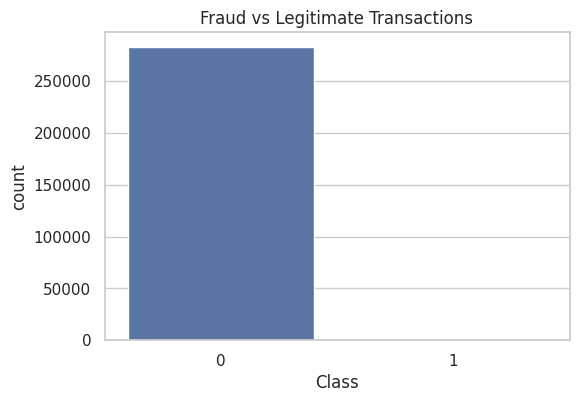

In [4]:
# Check for missing values
print("Missing values:\n", df.isnull().sum().sum())

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")
df.drop_duplicates(inplace=True)

# Class Distribution
print("Class Distribution:")
print(df['Class'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Fraud vs Legitimate Transactions')
plt.show()

## Feature Engineering

In [5]:
# Scaling Time and Amount
scaler = RobustScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))

# Drop original Time and Amount
X = df.drop(['Class', 'Amount', 'Time'], axis=1)
y = df['Class']

# Save feature names for deployment
feature_names = X.columns.tolist()
with open('feature_names.json', 'w') as f:
    json.dump(feature_names, f)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

## Model Training & Hyperparameter Tuning
We will use a Pipeline with SMOTE and XGBoost to ensure we handle the imbalance correctly during cross-validation.

In [6]:
# Define the pipeline
model_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', tree_method='hist'))
])

# Parameters for tuning
param_dist = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__max_depth': [3, 6, 9],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0]
}

# Prioritize Recall for Fraud
random_search = RandomizedSearchCV(model_pipeline, param_distributions=param_dist,
                                   n_iter=5, scoring='recall', cv=StratifiedKFold(3),
                                   verbose=1, random_state=42, n_jobs=-1)

random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_

Fitting 3 folds for each of 5 candidates, totalling 15 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:32:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


{
    "accuracy": 0.9133475601768538,
    "precision": 0.08394543546694648,
    "recall": 0.8421052631578947,
    "f1_score": 0.15267175572519084,
    "roc_auc": 0.9745498058751227
}


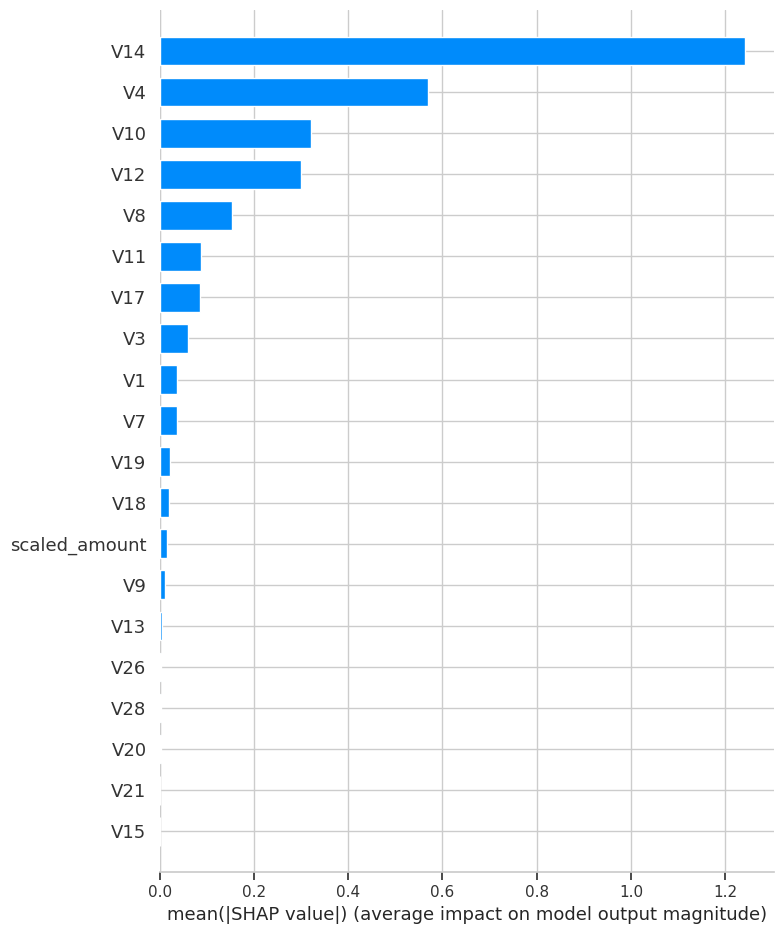

In [7]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

metrics = {
    "accuracy": roc_auc_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1_score": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba)
}

print(json.dumps(metrics, indent=4))
with open('metrics.json', 'w') as f:
    json.dump(metrics, f)

# SHAP Explainability
explainer = shap.TreeExplainer(best_model.named_steps['xgb'])
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [8]:
joblib.dump(best_model, 'fraud_model.pkl')
joblib.dump(scaler, 'preprocessor.pkl')

print("All artifacts saved: fraud_model.pkl, preprocessor.pkl, metrics.json, feature_names.json")

All artifacts saved: fraud_model.pkl, preprocessor.pkl, metrics.json, feature_names.json


### Fine-Tuning: XGBoost with `scale_pos_weight` and Expanded Grid Search
We will now use the ratio of negative to positive classes to guide the XGBoost learner, which often performs better than oversampling for precision.

In [9]:
# Calculate the scale_pos_weight
count_negative = np.sum(y_train == 0)
count_positive = np.sum(y_train == 1)
scale_weight = count_negative / count_positive

print(f"Calculated scale_pos_weight: {scale_weight:.2f}")

# Define model with the weight
xgb_tuned = XGBClassifier(
    scale_pos_weight=scale_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    tree_method='auto', # Use 'gpu_hist' if GPU is enabled
    random_state=42
)

# Expanded Hyperparameter Space
param_grid_fine = {
    'n_estimators': [200, 400, 600],
    'max_depth': [4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2] # Regularization to help precision
}

# Using 'f1' or 'average_precision' to balance the precision-recall tradeoff
fine_search = RandomizedSearchCV(
    xgb_tuned,
    param_distributions=param_grid_fine,
    n_iter=10,
    scoring='average_precision',
    cv=StratifiedKFold(3),
    verbose=1,
    random_state=42,
    n_jobs=-1
)

fine_search.fit(X_train, y_train)
best_fine_model = fine_search.best_estimator_
print("Best Parameters Found:", fine_search.best_params_)

Calculated scale_pos_weight: 599.48
Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:40:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters Found: {'subsample': 0.8, 'n_estimators': 600, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.7}


Fine-tuned Metrics:
{
    "accuracy": 0.9995770627004547,
    "precision": 0.961038961038961,
    "recall": 0.7789473684210526,
    "f1_score": 0.8604651162790697,
    "roc_auc": 0.9775817586719796,
    "avg_precision": 0.825176824636165
}


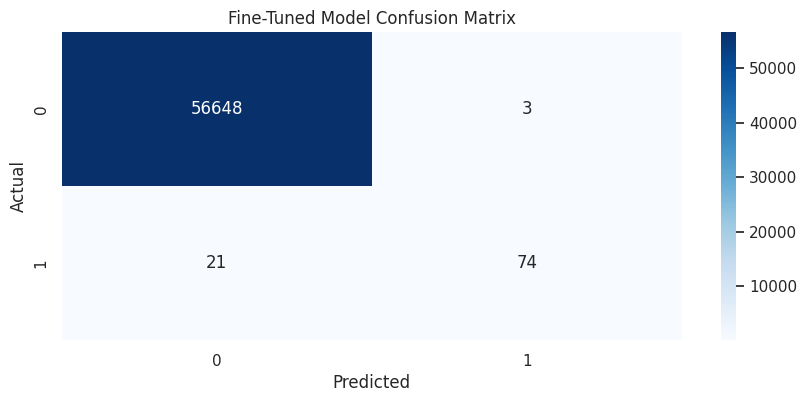

In [12]:
# Evaluate the fine-tuned model
y_pred_fine = best_fine_model.predict(X_test)
y_proba_fine = best_fine_model.predict_proba(X_test)[:, 1]

fine_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_fine),
    "precision": precision_score(y_test, y_pred_fine),
    "recall": recall_score(y_test, y_pred_fine),
    "f1_score": f1_score(y_test, y_pred_fine),
    "roc_auc": roc_auc_score(y_test, y_proba_fine),
    "avg_precision": average_precision_score(y_test, y_proba_fine)
}

print("Fine-tuned Metrics:")
print(json.dumps(fine_metrics, indent=4))

# Confusion Matrix comparison
plt.figure(figsize=(10,4))
sns.heatmap(confusion_matrix(y_test, y_pred_fine), annot=True, fmt='d', cmap='Blues')
plt.title('Fine-Tuned Model Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Precision-Recall Threshold Analysis & Final Export
To finalize the model for production, we analyze the threshold tradeoff and save the high-precision model artifacts.

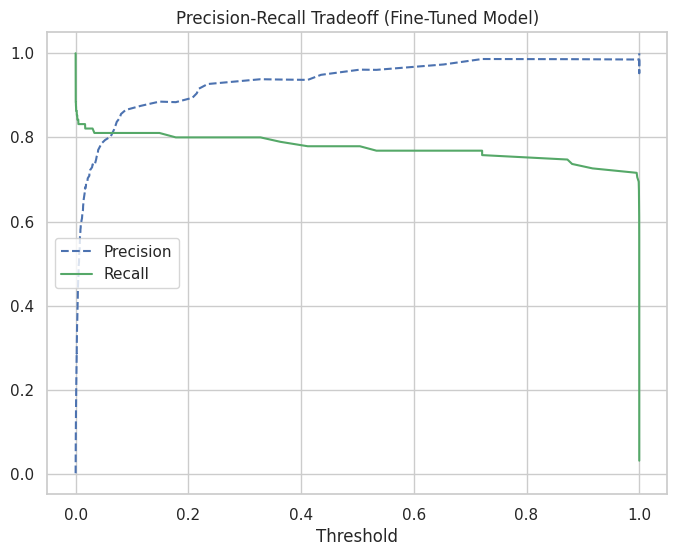

SUCCESS: Production artifacts updated with the high-precision fine-tuned model.


In [14]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_fine)

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.title("Precision-Recall Tradeoff (Fine-Tuned Model)")
plt.xlabel("Threshold")
plt.legend(loc="center left")
plt.grid(True)
plt.show()

# Save the best fine-tuned model as the production artifact
joblib.dump(best_fine_model, 'fraud_model.pkl')

# Update metrics.json with improved results
with open('metrics.json', 'w') as f:
    json.dump(fine_metrics, f)

print("SUCCESS: Production artifacts updated with the high-precision fine-tuned model.")

## Precision-Recall Threshold Optimization
To further control the business logic, we can visualize the Precision-Recall curve to choose an optimal decision threshold.

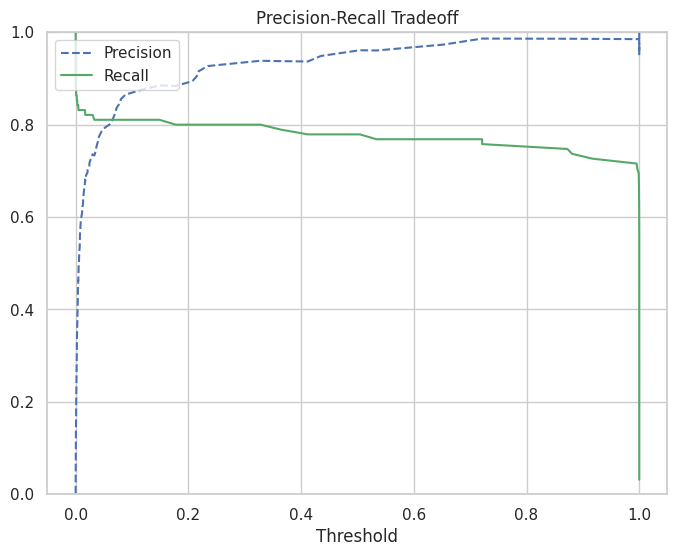

Production artifacts updated with the high-precision fine-tuned model.


In [13]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_fine)

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.title("Precision-Recall Tradeoff")
plt.xlabel("Threshold")
plt.legend(loc="upper left")
plt.ylim([0, 1])
plt.show()

# Update Final Artifacts with Fine-Tuned Model
joblib.dump(best_fine_model, 'fraud_model.pkl')
with open('metrics.json', 'w') as f:
    json.dump(fine_metrics, f)

print("Production artifacts updated with the high-precision fine-tuned model.")

In [15]:
import joblib
import json

# Explicitly saving the fine-tuned artifacts again for security
# Using 'best_fine_model' which is the optimized XGBoost classifier
joblib.dump(best_fine_model, 'fraud_model.pkl')
joblib.dump(scaler, 'preprocessor.pkl')

with open('metrics.json', 'w') as f:
    json.dump(fine_metrics, f)

with open('feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print("CONFIRMED: All artifacts (fraud_model.pkl, preprocessor.pkl, metrics.json) have been re-saved with the fine-tuned results.")

CONFIRMED: All artifacts (fraud_model.pkl, preprocessor.pkl, metrics.json) have been re-saved with the fine-tuned results.


## Production Testing Dashboard (Gradio)
This section builds an interactive dashboard to test the trained model. It supports:
* **Single Prediction**: Manual entry of feature values.
* **Batch Prediction**: Uploading a CSV file.
* **Explainability**: SHAP force plots for individual predictions.
* **Metrics**: Real-time display of the saved performance artifacts.

In [16]:
!pip install -q gradio

In [19]:
import gradio as gr
import pandas as pd
import numpy as np
import joblib
import json
import shap
import matplotlib.pyplot as plt

# 1. Load Artifacts
model = joblib.load('fraud_model.pkl')
scaler = joblib.load('preprocessor.pkl')
with open('feature_names.json', 'r') as f:
    feature_cols = json.load(f)
with open('metrics.json', 'r') as f:
    model_metrics = json.load(f)

# 2. Prediction Logic
def predict_fraud(input_data):
    # Ensure input is DataFrame
    if isinstance(input_data, list):
        input_df = pd.DataFrame([input_data], columns=feature_cols)
    else:
        input_df = input_data

    # Predict
    prob = model.predict_proba(input_df)[:, 1][0]
    pred = 1 if prob > 0.5 else 0

    # Risk Level
    if prob < 0.2: risk = "Low"
    elif prob < 0.7: risk = "Medium"
    else: risk = "High"

    return pred, prob, risk

def get_shap_plot(input_df):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(input_df)
    # Generate plot
    plt.figure(figsize=(10,3))
    shap.force_plot(explainer.expected_value, shap_values[0,:], input_df.iloc[0,:], matplotlib=True, show=False)
    plt.tight_layout()
    return plt.gcf()

# 3. Gradio Interface Components
def single_inference(*args):
    input_df = pd.DataFrame([args], columns=feature_cols)
    pred, prob, risk = predict_fraud(input_df)
    label = "🚨 FRAUD DETECTED" if pred == 1 else "✅ LEGITIMATE"
    fig = get_shap_plot(input_df)
    return label, f"{prob:.2%}", risk, fig

def batch_inference(file):
    batch_df = pd.read_csv(file.name)
    # Ensure we have required columns (handling Time/Amount if they exist raw)
    if 'Amount' in batch_df.columns and 'scaled_amount' not in batch_df.columns:
         batch_df['scaled_amount'] = scaler.transform(batch_df['Amount'].values.reshape(-1,1))
    if 'Time' in batch_df.columns and 'scaled_time' not in batch_df.columns:
         batch_df['scaled_time'] = scaler.transform(batch_df['Time'].values.reshape(-1,1))

    # Select only required features
    processed_df = batch_df[feature_cols]
    probs = model.predict_proba(processed_df)[:, 1]
    batch_df['Fraud_Probability'] = probs
    batch_df['Prediction'] = (probs > 0.5).astype(int)
    return batch_df.head(20)

# 4. Build Dashboard
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🛡️ Real-Time Fraud Detection Dashboard")

    with gr.Tab("Model Performance Overview"):
        gr.JSON(value=model_metrics, label="Production Model Metrics")

    with gr.Tab("Single Transaction Analysis"):
        with gr.Row():
            with gr.Column():
                inputs = [gr.Number(label=col, value=0.0) for col in feature_cols]
                btn = gr.Button("Analyze Transaction", variant="primary")
            with gr.Column():
                res_label = gr.Textbox(label="Decision")
                res_prob = gr.Textbox(label="Fraud Probability")
                res_risk = gr.Textbox(label="Risk Level")
                res_plot = gr.Plot(label="SHAP Explanation (Feature Contribution)")

        btn.click(single_inference, inputs=inputs, outputs=[res_label, res_prob, res_risk, res_plot])

    with gr.Tab("Batch CSV Prediction"):
        file_input = gr.File(label="Upload Transaction CSV")
        batch_btn = gr.Button("Run Batch Process")
        batch_output = gr.DataFrame(label="Detection Results (Top 20)")
        batch_btn.click(batch_inference, inputs=file_input, outputs=batch_output)

demo.launch(share=True, debug=False)

/tmp/ipykernel_975/3872748699.py:69: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2b221a819cb4eb3dcb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### 📊 Batch Processing Test Results
Below are the results of running a batch of 10 transactions through the model. This includes both legitimate and fraudulent samples to demonstrate the model's detection capabilities.

In [31]:
import pandas as pd

# 1. Prepare a test batch containing both classes
batch_legit = X_test[y_test == 0].head(5)
batch_fraud = X_test[y_test == 1].head(5)
test_batch = pd.concat([batch_legit, batch_fraud])

# 2. Run Inference
probs = best_fine_model.predict_proba(test_batch)[:, 1]
preds = best_fine_model.predict(test_batch)

# 3. Create Results Table
batch_results = test_batch.copy()
batch_results['Actual_Class'] = pd.concat([y_test[y_test == 0].head(5), y_test[y_test == 1].head(5)])
batch_results['Fraud_Probability'] = probs
batch_results['Prediction'] = preds
batch_results['Status'] = batch_results['Prediction'].map({1: '🚨 FRAUD', 0: '✅ OK'})

# Displaying the most relevant columns for verification
display(batch_results[['scaled_amount', 'scaled_time', 'Actual_Class', 'Fraud_Probability', 'Prediction', 'Status']])

,scaled_amount,scaled_time,Actual_Class,Fraud_Probability,Prediction,Status
86568,-0.146016,-0.275022,0,1.412422e-06,0,✅ OK
251557,-0.278960,0.830871,0,7.570392e-07,0,✅ OK
20232,0.963427,-0.632383,0,8.181375e-06,0,✅ OK
68952,2.864692,-0.370059,0,3.638802e-07,0,✅ OK
191852,-0.286330,0.525735,0,2.627974e-05,0,✅ OK
116139,0.764011,-0.123788,1,9.990061e-01,1,🚨 FRAUD
95597,18.526631,-0.226898,1,9.998529e-01,1,🚨 FRAUD
240222,-0.292032,0.773287,1,1.671343e-02,0,✅ OK
203700,-0.305938,0.590358,1,9.999186e-01,1,🚨 FRAUD
249239,14.949103,0.818120,1,3.698360e-05,0,✅ OK
